Best MI percentile:
Asset es1_logret: 56
Asset vg1_logret: 82
Asset z1_logret: 74
Asset rx1_logret: 56
Asset gc1_logret: 54
Asset co1_logret: 90
Asset hg1_logret: 90

Out-of-Sample prediction metrics:
                 MSE        R2  Directional Accuracy  Spearman
es1_logret  0.000203  0.679782              0.827476  0.773677
vg1_logret  0.000487  0.426894              0.709265  0.742318
z1_logret   0.000228  0.643631              0.715655  0.722850
rx1_logret  0.000102  0.093387              0.664537  0.438731
gc1_logret  0.000842 -0.933482              0.488818  0.340452
co1_logret  0.005213 -0.495063              0.667732  0.475270
hg1_logret  0.000184  0.810411              0.865815  0.888523

Optimized Portfolio Sharpe: 0.07
Benchmark Portfolio Sharpe: 0.07
Optimized Portfolio Max Drawdown: 28.91%
Benchmark Portfolio Max Drawdown: 29.61%
S&P Sharpe Ratio: 0.12


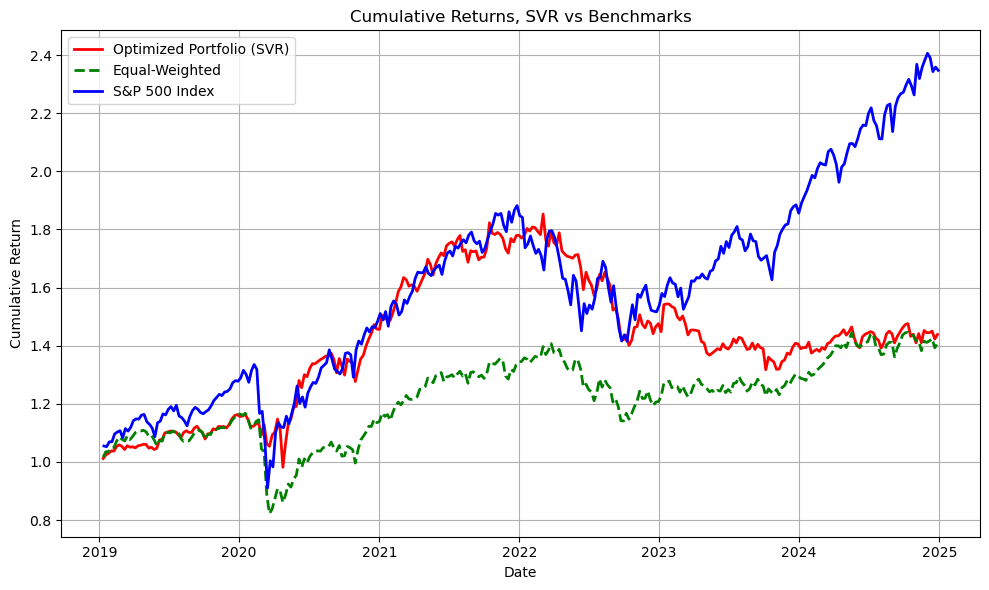

Processing time: 59 min


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.feature_selection import mutual_info_regression
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import time
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
np.random.seed(42)

start_time = time.time() 

###############################################################################
# 1. CVaR, Objective
###############################################################################
def compute_cvar(historical_returns, weights, alpha=0.9):
    port_returns = np.dot(historical_returns, weights)
    sorted_returns = np.sort(port_returns)
    cutoff = int(np.floor((1 - alpha) * len(sorted_returns)))
    cutoff = max(cutoff, 0)
    worst_returns = sorted_returns[:cutoff+1]
    cvar = np.mean(worst_returns) if len(worst_returns) > 0 else sorted_returns[cutoff]
    return cvar

def cvar_objective(weights, predicted_returns, historical_returns, alpha=0.9, lambda_reg=0.01):
    eps = 1e-8
    port_return = np.dot(weights, predicted_returns)
    port_cvar = compute_cvar(historical_returns, weights, alpha=alpha)
    return -port_return / (abs(port_cvar) + eps) + lambda_reg * np.sum(weights**2)

###############################################################################
# 2. SVR Hyperparameters space
###############################################################################
svr_param_space = {
    'C':      Real(1e-2, 1e2, prior='log-uniform'),
    'epsilon':Real(1e-5, 1e-1, prior='log-uniform'),
    'gamma':  Real(1e-6, 1e-1, prior='log-uniform')
}

###############################################################################
# 3. Data, train/test split
###############################################################################
price_data = pd.read_excel(
    r'C:\Users\orekh\Desktop\MMF\Thesis\Data\broader_weekly_data_filled.xlsx',
    parse_dates=["date"],
    index_col="date"
)

filtered_returns = price_data.iloc[:, :7]
filtered_features = price_data.iloc[:, 7:]
train_start_date = '2013-04-01'
train_end_date   = '2018-12-31'
test_start_date  = '2019-01-01'
test_end_date    = '2025-01-01'

train_returns = filtered_returns.loc[train_start_date:train_end_date]
train_features = filtered_features.loc[train_start_date:train_end_date]
test_returns = filtered_returns.loc[test_start_date:test_end_date]
test_features = filtered_features.loc[test_start_date:test_end_date]

all_test_dates = test_returns.index

###############################################################################
# 4. Scaling 
###############################################################################
scaler = StandardScaler()
train_features_scaled = pd.DataFrame(
    scaler.fit_transform(train_features),
    index=train_features.index,
    columns=train_features.columns
)
test_features_scaled = pd.DataFrame(
    scaler.transform(test_features),
    index=test_features.index,
    columns=test_features.columns
)

###############################################################################
# 5. Adaptive feature selection & model training (once), MI percentile grid search
###############################################################################
svr_models = {}
selected_features = {}
in_sample_metrics = {}

candidate_percentiles = list(range(50, 91, 2))

for asset in train_returns.columns:
    best_cv_score = -np.inf
    best_threshold = None
    best_model_for_asset = None
    best_selected_features = None
    
    mi_scores = mutual_info_regression(train_features_scaled, train_returns[asset], random_state=42)
    
    for percentile in candidate_percentiles:
        threshold_value = np.percentile(mi_scores, percentile)
        keep_idxs = np.where(mi_scores >= threshold_value)[0]
        
        if len(keep_idxs) == 0:
            continue
        
        features_tmp = train_features_scaled.columns[keep_idxs]
        X_train = train_features_scaled[features_tmp].values
        y_train = train_returns[asset].values
        
        # Time-series cross-validation and Bayesian hyperparameter search
        cv = TimeSeriesSplit(n_splits=3)
        opt = BayesSearchCV(
            SVR(),
            svr_param_space,
            n_iter=25,
            cv=cv,
            n_jobs=-1,
            scoring='neg_mean_squared_error',
            random_state=42
        )
        opt.fit(X_train, y_train)
        
        if opt.best_score_ > best_cv_score:
            best_cv_score = opt.best_score_
            best_threshold = percentile
            best_model_for_asset = opt.best_estimator_
            best_selected_features = features_tmp
    
    # Save the best
    selected_features[asset] = best_selected_features if best_selected_features is not None else []
    svr_models[asset] = best_model_for_asset
    
    # In-sample metrics
    if best_model_for_asset is not None:
        X_train_best = train_features_scaled[best_selected_features].values
        y_train = train_returns[asset].values
        y_train_pred = best_model_for_asset.predict(X_train_best)
        in_sample_metrics[asset] = {
            "MSE": mean_squared_error(y_train, y_train_pred),
            "R2": r2_score(y_train, y_train_pred),
            "Directional Accuracy": np.mean(np.sign(y_train) == np.sign(y_train_pred)),
            "Spearman": spearmanr(y_train, y_train_pred)[0],
            "Best MI percentile": best_threshold
        }

# Best mutual information percentile for each
print("Best MI percentile:")
for asset, metrics in in_sample_metrics.items():
    print(f"Asset {asset}: {metrics['Best MI percentile']}")

###############################################################################
# 6. Out-of-sample predictions & prediction metrics
###############################################################################
predictions = pd.DataFrame(index=test_features_scaled.index, columns=test_returns.columns)

for asset in test_returns.columns:
    if svr_models[asset] is not None:
        X_test = test_features_scaled[selected_features[asset]].values
        predictions[asset] = svr_models[asset].predict(X_test)
    else:
        predictions[asset] = 0.0

out_sample_metrics = {}
for asset in test_returns.columns:
    y_true = test_returns[asset]
    y_pred = predictions[asset]
    
    mse_val = mean_squared_error(y_true, y_pred)
    mae_val = mean_absolute_error(y_true, y_pred)
    r2_val = r2_score(y_true, y_pred)
    directional_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
    spearman_corr, _ = spearmanr(y_true, y_pred)
    
    out_sample_metrics[asset] = {
        "MSE": mse_val,
        "R2": r2_val,
        "Directional Accuracy": directional_accuracy,
        "Spearman": spearman_corr
    }

out_sample_metrics_df = pd.DataFrame(out_sample_metrics).T
print("\nOut-of-Sample prediction metrics:")
print(out_sample_metrics_df)

###############################################################################
# 7. Portfolio Construction
###############################################################################
optimized_portfolio_returns = []
benchmark_returns = []
optimized_weights_list = []
prev_weights = np.ones(len(train_returns.columns)) / len(train_returns.columns)

# Rebalance, use t-1 for correct investor logic
for t in range(1, len(test_returns)):
    expected_returns = predictions.iloc[t-1].fillna(0).values
    historical_returns = train_returns.values 

    n_assets = len(expected_returns)
    init_guess = np.ones(n_assets) / n_assets
    bounds = [(0, 1)] * n_assets
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: 0.4 - np.max(w)},
        {'type': 'ineq', 'fun': lambda w: np.min(w) - 0.0}
    ]
    
    if (t-1) % 2 == 0:
        res = minimize(
            cvar_objective,
            init_guess,
            args=(expected_returns, historical_returns, 0.95, 0.01),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )
        weights = res.x if res.success else init_guess
    else:
        weights = prev_weights
    
    turnover = np.sum(np.abs(weights - prev_weights))
    cost = 0.0001 * turnover
    realized_return = test_returns.iloc[t].values
    portfolio_return = np.dot(weights, realized_return)
    net_return = portfolio_return - cost

    optimized_portfolio_returns.append(net_return)
    benchmark_returns.append(np.dot(np.ones(n_assets)/n_assets, realized_return))
    optimized_weights_list.append(weights)
    prev_weights = weights.copy()

###############################################################################
# 8. Cumulative returns & portfolio metrics
###############################################################################
optimized_cumulative_returns = (1 + np.array(optimized_portfolio_returns)).cumprod()
benchmark_cumulative_returns = (1 + np.array(benchmark_returns)).cumprod()

def calculate_sharpe_ratio(returns, risk_free_rate=0):
    excess = np.array(returns) - risk_free_rate
    return np.mean(excess) / (np.std(excess, ddof=1) + 1e-9)

def calculate_max_drawdown(cum_returns):
    cum_max = np.maximum.accumulate(cum_returns)
    drawdown = (cum_max - cum_returns) / cum_max
    return np.max(drawdown)

sharpe_optimized = calculate_sharpe_ratio(optimized_portfolio_returns)
sharpe_benchmark = calculate_sharpe_ratio(benchmark_returns)
max_drawdown_optimized = calculate_max_drawdown(optimized_cumulative_returns)
max_drawdown_benchmark = calculate_max_drawdown(benchmark_cumulative_returns)

print(f"\nOptimized Portfolio Sharpe: {sharpe_optimized:.2f}")
print(f"Benchmark Portfolio Sharpe: {sharpe_benchmark:.2f}")
print(f"Optimized Portfolio Max Drawdown: {max_drawdown_optimized:.2%}")
print(f"Benchmark Portfolio Max Drawdown: {max_drawdown_benchmark:.2%}")

###############################################################################
# 9. S&P returns
###############################################################################
sp_data = pd.read_excel(
    r'C:\Users\orekh\Desktop\MMF\Thesis\Data\s_p_ret.xlsx',
    parse_dates=["date"],
    index_col="date"
)
sp_returns = sp_data['sp_ret']
sp_returns = sp_returns.loc[test_start_date:test_end_date]
sp_cumulative_returns = (1 + sp_returns).cumprod()
sharpe_sp = calculate_sharpe_ratio(sp_returns)
print(f"S&P Sharpe Ratio: {sharpe_sp:.2f}")

###############################################################################
# 10. Plot
###############################################################################
plt.figure(figsize=(10, 6))
plt.plot(all_test_dates[1:], optimized_cumulative_returns,
         label='Optimized Portfolio (SVR)', color='red', linewidth=2)
plt.plot(all_test_dates[1:], benchmark_cumulative_returns,
         label='Equal-Weighted', color='green', linestyle='--', linewidth=2)
sp_cumulative_returns_plot = sp_cumulative_returns[1:]
plt.plot(sp_cumulative_returns_plot.index, sp_cumulative_returns_plot,
         label='S&P 500 Index', color='blue', linewidth=2)
plt.title('Cumulative Returns, SVR vs Benchmarks')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

end_time = time.time()
print("Processing time: {:.0f} min".format((end_time - start_time) / 60))